# 导入所需模块
导入处理NetCDF数据和绘图所需的 Python 核心库。

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset
import os
from scipy.ndimage import gaussian_filter1d

# 设置数据文件路径及标签
定义三个 NetCDF 数据文件路径及对应的方案标签。

In [6]:
datasets = {
    'Thompson': 'dataset/wind_Thompson.nc',
    'Qzyx': 'dataset/wind_Qzyx.nc',
    'Kessler': 'dataset/wind_km.nc'
}

# 计算最大切向风速
遍历所有文件，读取时间及方位角平均切向风 `ut` 并且提取每个时刻高度和半径面上的最大值，作为台风强度。

In [7]:
# 保存所有数据集的时间和最大风速
results_time = {}
results_ut_max = {}

for label, filepath in datasets.items():
    if not os.path.exists(filepath):
        print(f"File not found: {filepath}")
        continue
        
    with Dataset(filepath, 'r') as nc:
        # 获取时间(秒转换为小时)
        time_s = np.asarray(nc.variables['time'][:], dtype=float)
        time_h = time_s / 3600.0
        
        # 获取 ut 数据: 形如 (time, z, r)
        ut = np.asarray(nc.variables['ut'][:], dtype=float)
        
        # 寻找随时间的各高度层各半径点上的最大值
        ut_max = np.nanmax(ut, axis=(1, 2))
        
        results_time[label] = time_h
        results_ut_max[label] = ut_max


# 绘制强度对比图
将三组实验的最大切向风强度演变图绘制在一起，展现 1-180h 的过程。

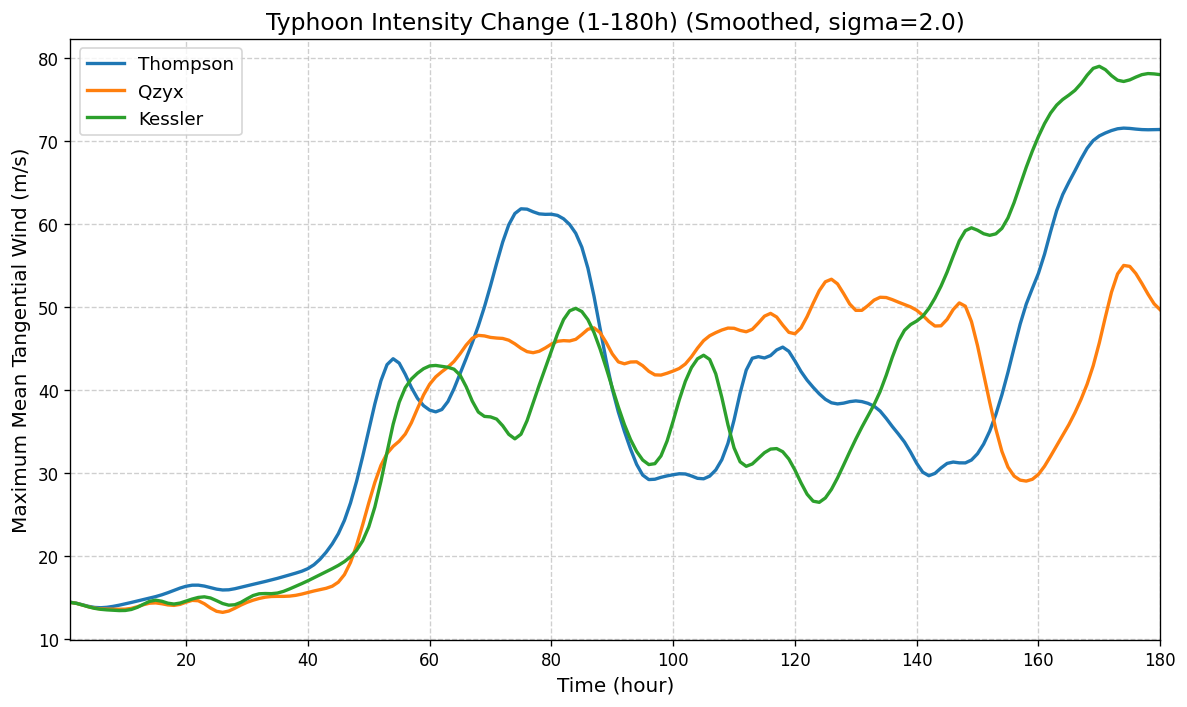

In [8]:
# 平滑选项
apply_smoothing = True
smooth_sigma = 2.0  # 高斯核标准差，决定平滑程度

plt.figure(figsize=(10, 6), dpi=120)

for label in datasets.keys():
    if label in results_time and label in results_ut_max:
        # 只提取 1h 到 180h 之间的数据
        t = results_time[label]
        ut_m = results_ut_max[label]
        
        mask = (t >= 1.0) & (t <= 180.0)
        t_plot = t[mask]
        ut_plot = ut_m[mask]
        
        if apply_smoothing:
            ut_plot = gaussian_filter1d(ut_plot, sigma=smooth_sigma)
            
        plt.plot(t_plot, ut_plot, linewidth=2.0, label=label)

title_suffix = f" (Smoothed, sigma={smooth_sigma})" if apply_smoothing else ""
plt.title(f'Typhoon Intensity Change (1-180h){title_suffix}', fontsize=14)
plt.xlabel('Time (hour)', fontsize=12)
plt.ylabel('Maximum Mean Tangential Wind (m/s)', fontsize=12)
plt.xlim(1, 180)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()